# Alpha Research Pipeline

7-step template: Signal -> Rank -> Position -> Shift -> Returns -> Combine -> Evaluate

Uses `data_loader.py` and `alpha_utils.py`
In this notebook : load data -> define signal -> call `evaluate_alpha()` -> plot.

In [1]:
import matplotlib.pyplot as plt
from data_loader import load_data, get_close_prices, get_volume, get_open_prices
from alpha_utils import evaluate_alpha
from alpha_utils import SPLIT_DATE
from alpha_utils import ts_rank, ts_min, ts_max
from alpha_utils import rolling_corr
from alpha_utils import get_liquidity_universe
from alpha_utils import plot_alpha
import numpy as np 
import pandas as pd 
import warnings
from scipy.stats import ConstantInputWarning
warnings.filterwarnings('ignore', category=ConstantInputWarning)

data = load_data()
close = get_close_prices(data)
open_px = get_open_prices(data)
volume = get_volume(data)
n_stocks = close.shape[1]
print(close.shape)

Loading cached data from data/sp500_5y.parquet
(1255, 503)


In [2]:
print(data.columns.get_level_values(1).unique())

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Adj Close'], dtype='object', name='Price')


## 12-1 Month Momentum
                

In [3]:
close = get_close_prices(data)

In [4]:
signal = (close.shift(21)/close.shift(252)) - 1

In [5]:
universe = get_liquidity_universe(close, volume, n_stocks=100, direction='largest')
signal_subset = signal[universe]
close_subset = close[universe]

In [6]:
results_mm = evaluate_alpha(signal_subset, close_subset, n_stocks=100)
print("Sharpe:", results_mm["sharpe"])
print("IC mean:", results_mm["ic_mean"])
print("ICIR:", results_mm["icir"])

Sharpe: 0.8864296718751451
IC mean: 0.025592560084084483
ICIR: 0.08985260349568149


### OOS Train and Test for 12-1 Month Momentum

In [7]:
results_mm = evaluate_alpha(signal_subset, close_subset, n_stocks=100)
print("train_sharpe:", results_mm['train_sharpe'])
print("train_ic:", results_mm["train_ic"])
print("test_sharpe:", results_mm['test_sharpe'])
print("test_ic:", results_mm["test_ic"])

train_sharpe: 0.9735228558744612
train_ic: 0.02486955901044087
test_sharpe: 0.8041657656184061
test_ic: 0.02679627995669327


### Plot 12-1 Month Momentum

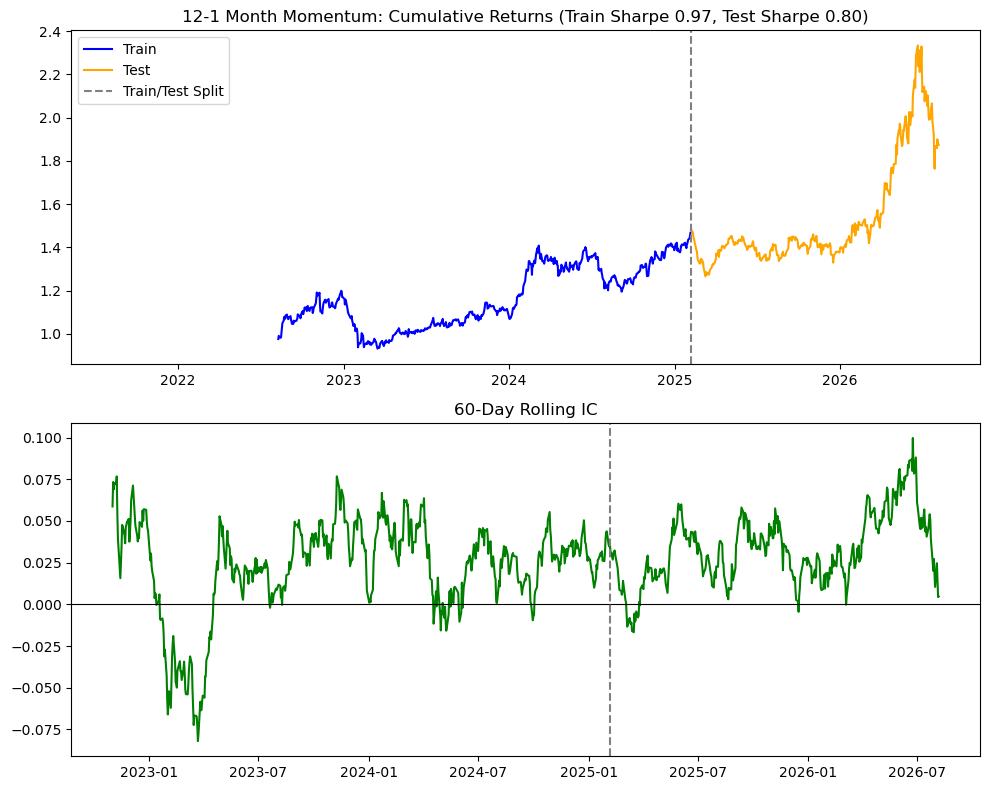

In [8]:
plot_alpha(results_mm, SPLIT_DATE, "12-1 Month Momentum")

### 12-1 Month Momentum Summary

Signal : 11 month returns (skipping the most recent month)

Universe : Top 100 stocks (large-cap within S&P 500)

Weighting : rank strength

full sample sharpe = 0.8864 | IC mean = 0.0255

Train : Sharpe = 0.9735 | IC Mean = 0.0248

Test/OOS : Sharpe = 0.8041 | IC mean = 0.0267
